In [1]:
#necessary imports
import sklearn as sk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from array_temp.DataPreprocessing import make_sequence_datasets


from data_tools import query
from data_tools.collections import TimeSeries
from datetime import datetime, date, time, timezone
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import dill
import os
import pytz
from datetime import datetime, time, date

In [2]:
# query data from influx. looking at timestamps of 2024 FSGP: 14 - 18 overall, but for smaller data response lets try 14 -16

#each 5 seconds
utc_offset_h = 7
start_utc = time(0+utc_offset_h, 00, 00)  #querying i svancouver time, influxdb gives utc
stop_utc = time(16+utc_offset_h, 45, 00)
date_start = date(2024, 7, 16)
date_stop = date(2024, 7, 18)

vancouver = pytz.timezone("America/Vancouver")

start_local = vancouver.localize(datetime.combine(date_start, start_utc))
stop_local = vancouver.localize(datetime.combine(date_stop, stop_utc))

start_time = start_local.astimezone(pytz.utc)
stop_time = stop_local.astimezone(pytz.utc)

client = query.DBClient()
mech_brake_pressed: TimeSeries = client.query_time_series(start_time, stop_time, field="MechBrakePressed")
accel_position: TimeSeries =   client.query_time_series(start_time, stop_time, field="AcceleratorPosition")
speed_kph: TimeSeries = client.query_time_series(start_time, stop_time, "VehicleVelocity")



In [3]:

# save collected data

out_dir = os.path.join("../../array_temp", "data", "control_state_fsgp_2024")
os.makedirs(out_dir, exist_ok=True)

brake_path = os.path.join(out_dir, "brake_pressed.bin")
accel_path = os.path.join(out_dir, "acceleration.bin")
speed_path = os.path.join(out_dir, "speed_kph.bin")

filepaths = [brake_path, accel_path, speed_path]
datasets = [mech_brake_pressed, accel_position, speed_kph]

for filepath, data in zip(filepaths, datasets):
    with open(filepath, "wb") as f:
        dill.dump(data, f)


In [2]:
#loading data
import os
import dill
out_dir = os.path.join("../../array_temp", "data", "control_state_fsgp_2024")

brake_path = os.path.join(out_dir, "brake_pressed.bin")
accel_path = os.path.join(out_dir, "acceleration.bin")
speed_path = os.path.join(out_dir, "speed_kph.bin")

filepaths = [brake_path, accel_path, speed_path]

loaded_datasets = []

for filepath in filepaths:
    with open(filepath, "rb") as f:
        data = dill.load(f)
        loaded_datasets.append(data)

#unnpack
mech_brake_pressed, accel_position, speed_kph = loaded_datasets

In [3]:
# use sunbeam instead to save yourself a headache
from data_tools import *
import numpy as np
def make_df(source, name):
    dfs = []

    client = query.SunbeamClient()

    for event in ["FSGP_2024_Day_1", "FSGP_2024_Day_2", "FSGP_2024_Day_3"]:
        file = client.get_file(
            origin="production",
            event=event,
            source=source,
            name=name
        ).unwrap()

        dfs.append(
            pd.DataFrame(
                data=file.data,
                index=file.data.datetime_x_axis
            )
        )

    return pd.concat(dfs).sort_index()

In [4]:
pos = []
pos_df = make_df(source = "localization", name = "TrackIndex")

In [5]:

speed_df = make_df(source = "ingress", name = "VehicleVelocity")

In [6]:
speed_df.head()

,0
2024-07-16 07:49:53.627000093,0.0
2024-07-16 07:49:53.827000618,0.0
2024-07-16 07:49:54.027000904,0.0
2024-07-16 07:49:54.227001429,0.0
2024-07-16 07:49:54.427001953,0.0


In [7]:
# combine all dfs and resample, then feed to scaler.
# states = velocity, position
# control = mbrake pressed, accelerator position
def combine_dfs(telemetry_names, index_common, all_dfs):
        combined_df = pd.DataFrame(index=index_common)
        combined_df.dropna()

        for name, df in zip(telemetry_names, all_dfs):
            #df_interp = self.resample(df, index_common)
            combined_df[name] = df

        return combined_df


In [15]:
#preprocessing - convert everything to pandas dataframes.


df_mech_brake_pressed = pd.DataFrame(mech_brake_pressed, index = mech_brake_pressed.datetime_x_axis)
df_accel_position = pd.DataFrame(accel_position, index = accel_position.datetime_x_axis)
#df_speed_kph = pd.DataFrame(speed_kph)



all_dfs = [df_mech_brake_pressed, df_accel_position]
combined_df = combine_dfs(["mech_brake_pressed", "accel_position"], df_mech_brake_pressed.index, all_dfs)


In [12]:
df_accel_position.head()

,0
2024-07-16 07:49:53.648000002,0.0
2024-07-16 07:49:53.747999907,0.0
2024-07-16 07:49:53.848000050,0.0
2024-07-16 07:49:53.947999954,0.0
2024-07-16 07:49:54.048000097,0.0


In [21]:
final_df = pd.merge_asof(
    df_mech_brake_pressed.sort_index(),
    df_accel_position.sort_index(),
    left_index=True,
    right_index=True,
    direction="nearest"
)

In [22]:
final_df.head()

,0_x,0_y
2024-07-16 07:05:27.380000114,0.0,0.0
2024-07-16 07:05:27.480000019,0.0,0.0
2024-07-16 07:05:27.580000162,0.0,0.0
2024-07-16 07:05:27.680000067,0.0,0.0
2024-07-16 07:05:27.780000210,0.0,0.0


In [18]:
all_dfs.head()

,0,0
2024-07-16 07:05:27.380000114,0.0,NaN
2024-07-16 07:05:27.480000019,0.0,NaN
2024-07-16 07:05:27.580000162,0.0,NaN
2024-07-16 07:05:27.680000067,0.0,NaN
2024-07-16 07:05:27.780000210,0.0,NaN


In [23]:

dfs = pd.concat([pos_df, speed_df], axis = 1)
#df = (["position", "speed"], pos_df.index, dfs)

In [28]:
final_df = pd.merge_asof(
    final_df.sort_index(),
    dfs.sort_index(),
    left_index=True,
    right_index=True,
    direction="nearest"
)

In [24]:
dfs.sort_index().head()

,TrackIndexSpreadsheet,0
2024-07-16 07:49:53.627000093,0.0,0.0
2024-07-16 07:49:53.827000618,0.0,0.0
2024-07-16 07:49:54.027000904,0.0,0.0
2024-07-16 07:49:54.227001429,0.0,0.0
2024-07-16 07:49:54.427001953,0.0,0.0


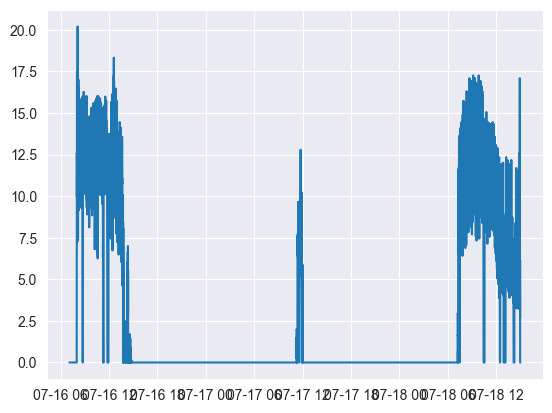

In [30]:
plt.plot(final_df[0])

In [32]:
final_df.columns = ["brake_pressed", "accel_position", "position", "speed"]

In [33]:
final_df.head()

,brake_pressed,accel_position,position,speed
2024-07-16 07:05:27.380000114,0.0,0.0,0.0,0.0
2024-07-16 07:05:27.480000019,0.0,0.0,0.0,0.0
2024-07-16 07:05:27.580000162,0.0,0.0,0.0,0.0
2024-07-16 07:05:27.680000067,0.0,0.0,0.0,0.0
2024-07-16 07:05:27.780000210,0.0,0.0,0.0,0.0


In [35]:
print(final_df.isna().sum())
print(final_df.shape)
# position has nan values

brake_pressed          0
accel_position         0
position          825917
speed                  0
dtype: int64
(2011945, 4)


In [36]:
final_df = final_df.sort_index()
final_df = final_df.ffill().dropna()

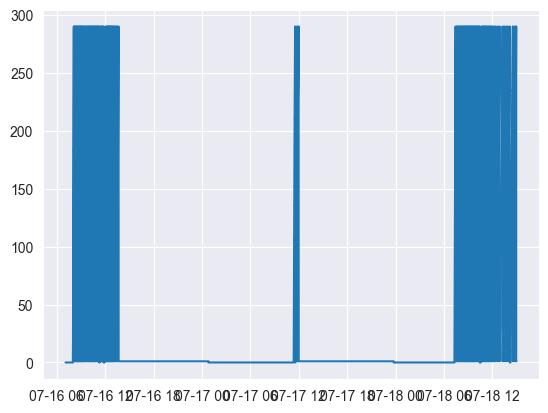

In [38]:
plt.plot(final_df["position"])

In [53]:
#finally cleared up all data, now move onto RNN
import DataPreprocessing
train_dataset, test_dataset, train_loader, test_loader, scaler = DataPreprocessing.make_sequence_datasets(final_df, state_cols = ['position', 'speed'], control_cols = ['brake_pressed', 'accel_position'], seq_len = 3000, train_frac=0.7, batch_size = 64)

In [54]:
state = ['position', 'speed']
control = ['brake_pressed', 'accel_position']

In [55]:
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader
from sklearn.preprocessing import StandardScaler
from RNN_Dataset import RNN_Dataset

In [56]:

from RNN import *
seq_length = 3000
input_size = len(state)
output_size = len(control)


hidden_size = 128     # was 256
num_layers  = 2
model = RNN(input_size, hidden_size, num_layers, seq_length, output_size).to(device)

In [57]:
# now we define the training loop. we are pretending a trajectory of controls.

#build the model


def train_model(model, train_loader, test_loader, epochs):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)
    train_losses = []
    test_losses = []
    print("NaNs in Train Loader:", any(torch.isnan(x).any() for x, y in train_loader))
    print("NaNs in Test Loader:", any(torch.isnan(x).any() for x, y in test_loader))
    for epoch in range(epochs):

        #training loop
        model.train()
        train_loss = 0
        for x_batch, y_batch in train_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            #check inputs before forward pass
            if torch.isnan(x_batch).any() or torch.isnan(y_batch).any():
                print("NaN in inputs, skipping batch")
                continue


          #  optimizer.zero_grad() #resets the gradients to zero
            outputs = model(x_batch)
            loss = criterion(outputs, y_batch)
            if torch.isnan(outputs).any():
                print("NaN in model outputs")
                print("x_batch min/max:", x_batch.min().item(), x_batch.max().item())
                continue

            loss = criterion(outputs, y_batch)

            if torch.isnan(loss):
                print("NaN in loss")
                print("outputs min/max:", outputs.min().item(), outputs.max().item())
                print("y_batch min/max:", y_batch.min().item(), y_batch.max().item())
                continue
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1)
            optimizer.step()

            train_loss += loss.item() #convert tensor to float
        train_loss/=len(train_loader) #average losses over batches
        print(f"Epoch {epoch + 1}/{epochs}, Train Loss: {train_loss:.4f}")
        train_losses.append(train_loss)

        # testing loop
        model.eval()
        test_loss = 0
        with torch.no_grad():
            for x_batch, y_batch in test_loader:
                x_batch = x_batch.to(device)
                y_batch = y_batch.to(device)
                optimizer.zero_grad()
                predictions = model(x_batch)
                loss = criterion(predictions, y_batch)
                test_loss += loss.item()
        test_loss/=len(test_loader)
        test_losses.append(test_loss)

    return train_losses, test_losses

In [58]:
train_losses, test_losses = train_model(model, train_loader, test_loader, epochs=50)

# Save
torch.save({
    'model_state_dict': model.state_dict(),
    'input_size': input_size,
    'hidden_size': hidden_size,
    'num_layers': num_layers,
    'seq_length': seq_len,
    'output_size': output_size,
}, 'rnn_model.pt')

NaNs in Train Loader: False
NaNs in Test Loader: False


KeyboardInterrupt: 

In [ ]:
#remember we also need to save the scaler to apply at inference
#using job lib for this purpose
import joblib
joblib.dump(scaler, 'scaler.pkl')

# Later at inference
scaler = joblib.load('scaler.pkl')
x_new_scaled = scaler.transform(x_new_raw)

In [ ]:
#now we evaluate model for inference
checkpoint = torch.load('rnn_model.pt', map_location=device)

model = RNN(
    input_size  = checkpoint['input_size'],
    hidden_size = checkpoint['hidden_size'],
    num_layers  = checkpoint['num_layers'],
    seq_length  = checkpoint['seq_length'],
    output_size = checkpoint['output_size'],
)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()  # important — disables dropout/batchnorm for inference

In [40]:
print("Any inf in final_df:", np.isinf(final_df.values).any())
print("Any NaN in final_df:", np.isnan(final_df.values).any())

Any inf in final_df: False
Any NaN in final_df: False


koko


In [47]:
import torch
import torch.nn as nn
import numpy as np
from RNN import RNN

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"


def train_rnn(
    train_loader,
    test_loader,
    input_size,
    output_size,
    hidden_size=128,
    num_layers=2,
    seq_length=50,
    num_epochs=50,
    learning_rate=1e-3,
    patience=10,
    save_path="best_rnn.pt",
):
    """
    Train an RNN (LSTM) model on sequence data.

    Args:
        train_loader:   DataLoader for training set
        test_loader:    DataLoader for validation/test set
        input_size:     Number of input features (len(state_cols))
        output_size:    Number of output features (len(control_cols))
        hidden_size:    LSTM hidden dimension
        num_layers:     Number of stacked LSTM layers
        seq_length:     Sequence length (must match dataset seq_len)
        num_epochs:     Maximum training epochs
        learning_rate:  Adam learning rate
        patience:       Early stopping patience (epochs without val improvement)
        save_path:      Where to save the best model weights

    Returns:
        model:          Trained RNN model (best weights loaded)
        history:        Dict with 'train_loss' and 'val_loss' lists
    """

    model = RNN(
        input_size=input_size,
        hidden_size=hidden_size,
        num_layers=num_layers,
        seq_length=seq_length,
        output_size=output_size,
    ).to(device)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    # Reduce LR if val loss plateaus
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=patience // 2
    )

    history = {"train_loss": [], "val_loss": []}
    best_val_loss = float("inf")
    epochs_no_improve = 0

    for epoch in range(1, num_epochs + 1):

        # ── Training ──────────────────────────────────────────────
        model.train()
        train_losses = []

        for x_batch, y_batch in train_loader:
            x_batch = x_batch.to(device)   # [B, seq_len, input_size]
            y_batch = y_batch.to(device)   # [B, seq_len, output_size]

            optimizer.zero_grad()
            preds = model(x_batch)         # [B, seq_len, output_size]
            loss = criterion(preds, y_batch)
            loss.backward()

            # Gradient clipping to prevent exploding gradients in LSTMs
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()
            train_losses.append(loss.item())

        # ── Validation ────────────────────────────────────────────
        model.eval()
        val_losses = []

        with torch.no_grad():
            for x_batch, y_batch in test_loader:
                x_batch = x_batch.to(device)
                y_batch = y_batch.to(device)

                preds = model(x_batch)
                loss = criterion(preds, y_batch)
                val_losses.append(loss.item())

        train_loss = np.mean(train_losses)
        val_loss   = np.mean(val_losses)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        scheduler.step(val_loss)

        # ── Logging ───────────────────────────────────────────────
        print(
            f"Epoch [{epoch:>3}/{num_epochs}]  "
            f"Train Loss: {train_loss:.6f}  |  "
            f"Val Loss: {val_loss:.6f}"
        )

        # ── Early stopping + checkpoint ───────────────────────────
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), save_path)
            print(f"  ✓ New best model saved  (val_loss={best_val_loss:.6f})")
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"\nEarly stopping triggered after {epoch} epochs.")
                break

    # Load best weights before returning
    model.load_state_dict(torch.load(save_path, map_location=device))
    print(f"\nTraining complete. Best val loss: {best_val_loss:.6f}")
    return model, history


# ── Example usage ─────────────────────────────────────────────────────────────
if __name__ == "__main__":
    import pandas as pd
    from DataPreprocessing import make_sequence_datasets

    df = final_df

    state_cols   = ["position", "speed"]
    control_cols = ["brake_pressed", "accel_position"]

    seq_len    = 3000
    batch_size = 64

    train_dataset, test_dataset, train_loader, test_loader, scaler = make_sequence_datasets(
        df_xy        = df,
        state_cols   = state_cols,
        control_cols = control_cols,
        seq_len      = seq_len,
        stride       = 10,
        train_frac   = 0.8,
        batch_size   = batch_size,
    )

    model, history = train_rnn(
        train_loader = train_loader,
        test_loader  = test_loader,
        input_size   = len(state_cols),
        output_size  = len(control_cols),
        hidden_size  = 128,
        num_layers   = 2,
        seq_length   = seq_len,
        num_epochs   = 50,
        learning_rate= 1e-3,
        patience     = 10,
        save_path    = "rnn_first.pt",
    )

KeyboardInterrupt: 